In [3]:

import sys
!{sys.executable} -m pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdo

In [5]:
# ── Imports ──────────────────────────────────────────────
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, Input, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

print('✅ All imports successful')

✅ All imports successful


In [5]:
# ── Imports ──────────────────────────────────────────────
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, Input, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

print('✅ All imports successful')

✅ All imports successful


## ⚙️ Step 1 – Configuration
All tunable settings in one place. Change these to experiment!

In [6]:
WINDOW_SIZE   = 3      # how many past months the model sees at once
TRAIN_RATIO   = 0.80   # 80% training, 20% testing
EPOCHS        = 200    # full passes through training data
BATCH_SIZE    = 8      # samples before each weight update
RNN_UNITS     = 50     # neurons in the SimpleRNN layer
LEARNING_RATE = 0.001  # step size for Adam optimizer
FUTURE_STEPS  = 12     # months to forecast after training
OUTPUT_DIR    = 'outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(42)
tf.random.set_seed(42)
print('✅ Config set')

✅ Config set


## 📊 Step 2 – Load Dataset

In [7]:
passengers = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,  # 1949
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140,  # 1950
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166,  # 1951
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194,  # 1952
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,  # 1953
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229,  # 1954
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278,  # 1955
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306,  # 1956
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336,  # 1957
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,  # 1958
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405,  # 1959
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432,  # 1960
]

dates = pd.date_range(start='1949-01-01', periods=len(passengers), freq='MS')
df = pd.DataFrame({'Month': dates, 'Passengers': passengers})

print(f'Total months: {len(df)}')
print(f'Sliding window demo: {passengers[:3]} → {passengers[3]}')
df.head()

Total months: 144
Sliding window demo: [112, 118, 132] → 129


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


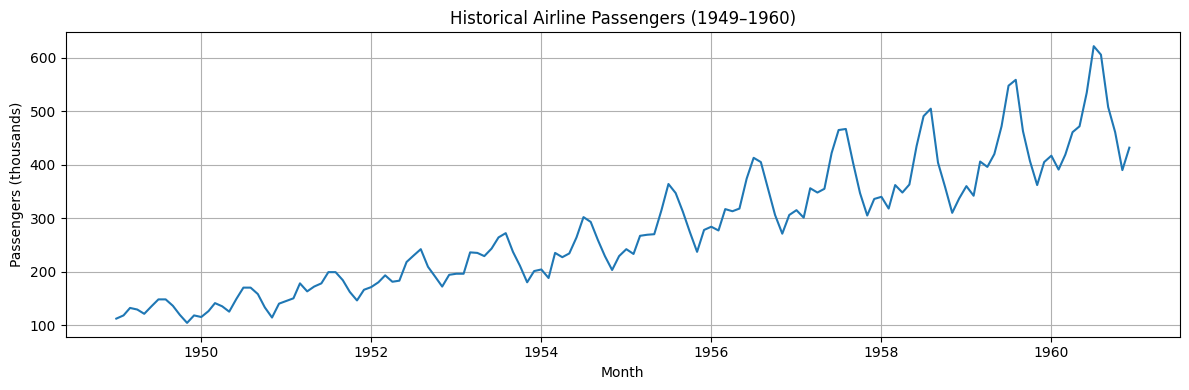

In [8]:
# Quick look at the raw data
plt.figure(figsize=(12, 4))
plt.plot(df['Month'], df['Passengers'])
plt.title('Historical Airline Passengers (1949–1960)')
plt.xlabel('Month'); plt.ylabel('Passengers (thousands)')
plt.grid(True); plt.tight_layout(); plt.show()

##  Step 3 – Preprocessing
**Why scale?** Neural networks train better when inputs are in a small range (0 to 1).

**Why fit scaler on training data only?** Fitting on the full dataset would let the model 'see' future values during training — this is called **data leakage**.

In [10]:
raw_passengers  = df[['Passengers']].values.astype(float)  # shape (144, 1)
total_sequences = len(raw_passengers) - WINDOW_SIZE
train_size      = int(total_sequences * TRAIN_RATIO)
train_end_index = train_size + WINDOW_SIZE

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(raw_passengers[:train_end_index])          # fit on train only!
scaled_passengers = scaler.transform(raw_passengers)  # transform all

print(f'Train end index  : {train_end_index}')
print(f'Scaled range     : {scaled_passengers.min():.3f} to {scaled_passengers.max():.3f}')

Train end index  : 115
Scaled range     : 0.000 to 1.339


## 🪟 Step 4 – Create Sliding Window Sequences
We slide a window of size 3 across the data to create input→output pairs:
```
i=0 → X=[112,118,132]  y=129
i=1 → X=[118,132,129]  y=121
i=2 → X=[132,129,121]  y=135  ...
```

In [11]:
def create_sequences(data, window_size):
    x_values, y_values = [], []
    for i in range(len(data) - window_size):
        x_values.append(data[i : i + window_size])  # input window
        y_values.append(data[i + window_size])       # next value = target
    return np.array(x_values), np.array(y_values)

X, y = create_sequences(scaled_passengers, WINDOW_SIZE)
target_dates = df['Month'].iloc[WINDOW_SIZE:].reset_index(drop=True)

print(f'X shape : {X.shape}  → (num_sequences, window_size, 1)')
print(f'y shape : {y.shape}  → (num_sequences,)')

X shape : (141, 3, 1)  → (num_sequences, window_size, 1)
y shape : (141, 1)  → (num_sequences,)


##  Step 5 – Train / Test Split
 **Never shuffle time-series data!** We keep chronological order so the model learns from the past to predict the future.

In [12]:
X_train, y_train = X[:train_size],  y[:train_size]
X_test,  y_test  = X[train_size:],  y[train_size:]
test_dates = target_dates.iloc[train_size:].reset_index(drop=True)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 112
Testing  samples : 29


##  Step 6 – Build the Vanilla RNN Model
```
Input  (3, 1)  →  SimpleRNN(50, tanh)  →  Dense(1)
```
- **SimpleRNN**: reads 3 months sequentially, outputs a 50-dim vector
- **Dense(1)**: maps that vector to a single prediction
- **tanh**: keeps gradients healthy (values between -1 and +1)

In [13]:
def build_simple_rnn_model(window_size, rnn_units, learning_rate):
    model = Sequential([
        Input(shape=(window_size, 1)),
        SimpleRNN(units=rnn_units, activation='tanh'),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

model = build_simple_rnn_model(WINDOW_SIZE, RNN_UNITS, LEARNING_RATE)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

##  Step 7 – Train the Model

In [14]:
history = model.fit(
    X_train, y_train,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.10,   # last 10% of train set used for validation
    shuffle          = False,   # preserve time order!
    verbose          = 1,
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0213 - val_loss: 0.0507
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0313 - val_loss: 0.0400
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0140 - val_loss: 0.0339
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0135 - val_loss: 0.0300
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0100 - val_loss: 0.0282
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093 - val_loss: 0.0262
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0084 - val_loss: 0.0243
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0081 - val_loss: 0.0231
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0076 - val_loss: 0.0219
Epoch 10/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074 - val_loss: 0.0210
Epoch 11/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0070 - val_loss: 0.0201
Epoch 12/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

##  Step 8 – Training Loss Curve
**What to look for:**
- Both curves decrease & level off → model is learning 
- val_loss rises while train_loss drops → **overfitting** 
- Both stay high → **underfitting** (try more epochs or units) 

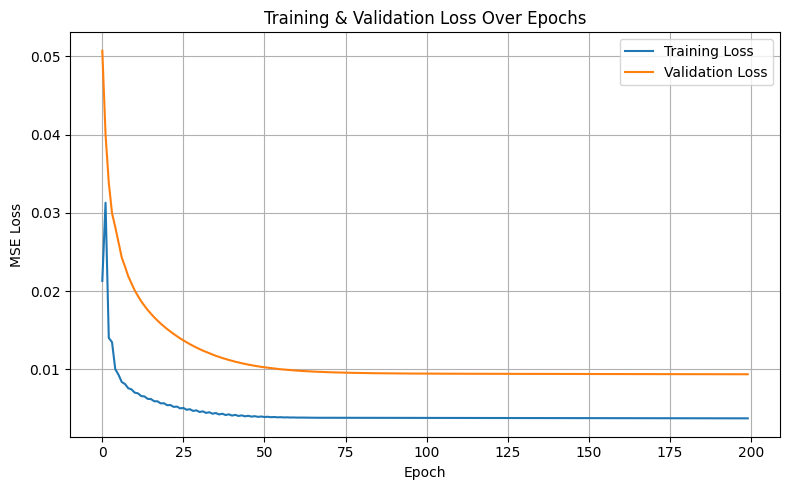

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_loss.png'), dpi=150)
plt.show()

##  Step 9 – Evaluate on Test Data

In [16]:
test_preds_scaled = model.predict(X_test, verbose=0)

# Inverse-transform: scaled values → real passenger counts
y_test_actual = scaler.inverse_transform(y_test).flatten()
y_test_preds  = scaler.inverse_transform(test_preds_scaled).flatten()

mse  = mean_squared_error(y_test_actual, y_test_preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, y_test_preds)

print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}  ← most interpretable (same unit as passengers)')
print(f'MAE  : {mae:.2f}  ← average error per prediction')

pd.DataFrame({'Month': test_dates, 'Actual': y_test_actual, 'Predicted': y_test_preds}).head(10)

MSE  : 2207.41
RMSE : 46.98  ← most interpretable (same unit as passengers)
MAE  : 39.39  ← average error per prediction


,Month,Actual,Predicted
0,1958-08-01,505.0,492.438690
1,1958-09-01,404.0,496.400299
2,1958-10-01,359.0,370.473175
3,1958-11-01,310.0,363.551971
4,1958-12-01,337.0,306.086945
5,1959-01-01,360.0,356.574036
6,1959-02-01,342.0,363.716003
7,1959-03-01,406.0,334.586212
8,1959-04-01,396.0,429.181274
9,1959-05-01,420.0,382.310242


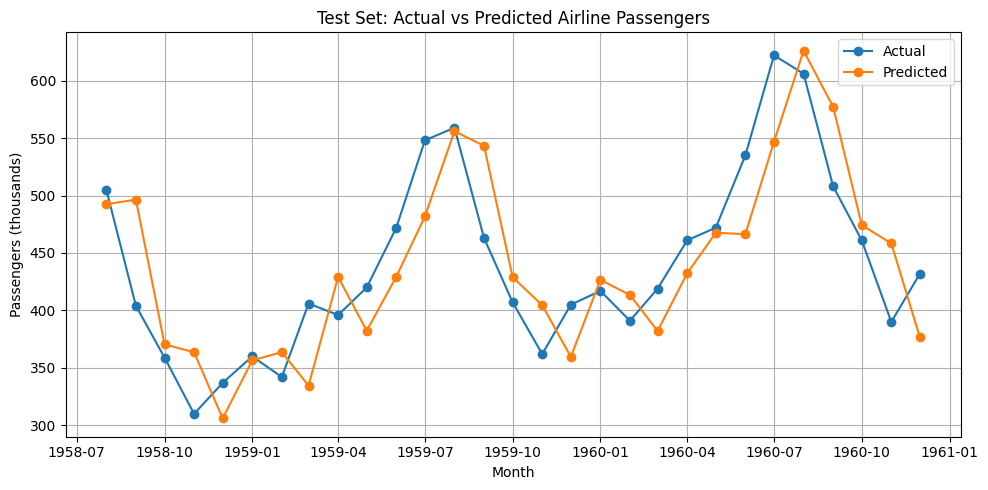

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_actual, marker='o', label='Actual')
plt.plot(test_dates, y_test_preds,  marker='o', label='Predicted')
plt.title('Test Set: Actual vs Predicted Airline Passengers')
plt.xlabel('Month'); plt.ylabel('Passengers (thousands)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'actual_vs_predicted.png'), dpi=150)
plt.show()

##  Step 10 – Forecast Next 12 Months
**Recursive (autoregressive) strategy:**
Each new prediction is fed back as input for the next step.
```
Iter 1: [m-3, m-2, m-1]        → predict m+1
Iter 2: [m-2, m-1, m+1]        → predict m+2
Iter 3: [m-1, m+1, m+2]        → predict m+3  ...
```
 Error accumulates over many steps since predictions depend on previous predictions.

In [18]:
def recursive_future_prediction(model, last_sequence, scaler, future_steps):
    future_scaled = []
    current_seq = last_sequence.copy()

    for _ in range(future_steps):
        model_input = current_seq.reshape(1, WINDOW_SIZE, 1)
        next_val = model.predict(model_input, verbose=0)[0, 0]
        future_scaled.append(next_val)
        # Slide window: drop oldest, add new prediction
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    future_preds = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1))
    return future_preds.flatten()

last_sequence  = scaled_passengers[-WINDOW_SIZE:]
future_preds   = recursive_future_prediction(model, last_sequence, scaler, FUTURE_STEPS)
future_dates   = pd.date_range(
    start   = df['Month'].iloc[-1] + pd.DateOffset(months=1),
    periods = FUTURE_STEPS, freq='MS'
)
future_df = pd.DataFrame({'Month': future_dates, 'Predicted Passengers': future_preds})
print(future_df.to_string(index=False))

     Month  Predicted Passengers
1961-01-01            456.279755
1961-02-01            455.264740
1961-03-01            449.745911
1961-04-01            447.291260
1961-05-01            446.641602
1961-06-01            446.083221
1961-07-01            445.281067
1961-08-01            444.423615
1961-09-01            443.627167
1961-10-01            442.893860
1961-11-01            442.202179
1961-12-01            441.543121


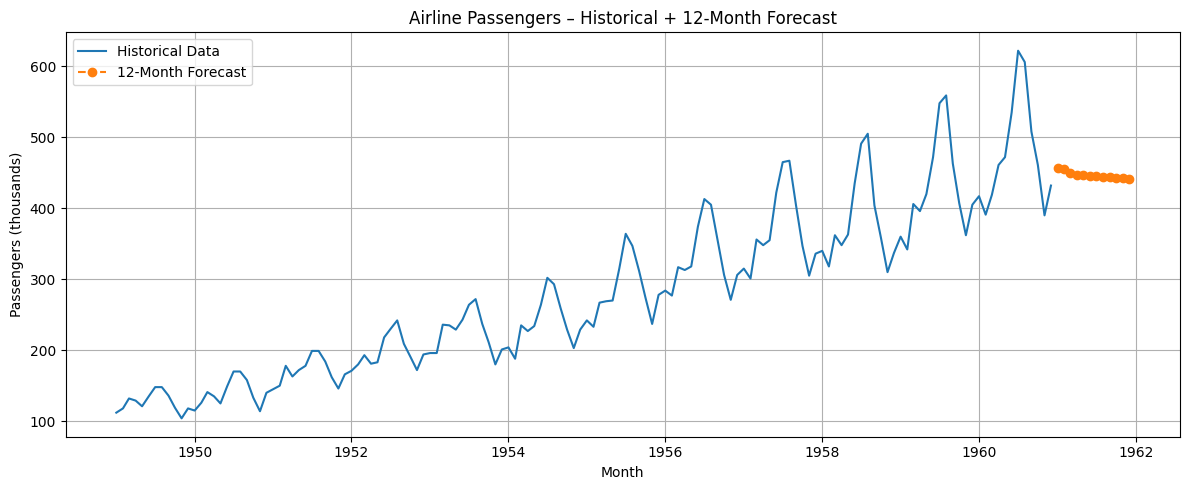

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df['Month'],        df['Passengers'],                  label='Historical Data')
plt.plot(future_df['Month'], future_df['Predicted Passengers'], marker='o',
         linestyle='--', label='12-Month Forecast')
plt.title('Airline Passengers – Historical + 12-Month Forecast')
plt.xlabel('Month'); plt.ylabel('Passengers (thousands)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'future_prediction.png'), dpi=150)
plt.show()
